In [1]:
import os
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

### Analyzing Images in Gallery and their Corresponding Embeddings

In [2]:
# Paths to the storage directories
GALLERY_STORAGE = "storage/gallery"
EMBEDDINGS_STORAGE = "storage/embeddings"

In [3]:
def load_images_from_gallery(gallery_path):
    images = []
    for folder in os.listdir(gallery_path):
        folder_path = os.path.join(gallery_path, folder)
        if not os.path.isdir(folder_path):  # Skip non-directory files
            continue
        for file in os.listdir(folder_path):
            if file.endswith('.jpg'):
                file_path = os.path.join(folder_path, file)
                images.append((folder, file, Image.open(file_path).convert('RGB')))
    return images


In [4]:
def load_embeddings(embedding_path):
    embeddings = []
    for root, _, files in os.walk(embedding_path):
        for file in files:
            if file.endswith('.npy'):
                file_path = os.path.join(root, file)
                embeddings.append((file, np.load(file_path)))
    return embeddings

In [5]:
# Load images and embeddings
images = load_images_from_gallery(GALLERY_STORAGE)
embeddings = load_embeddings(EMBEDDINGS_STORAGE)

In [6]:
output_dir = 'analysis'
os.makedirs(output_dir, exist_ok=True)

In [7]:
categories = [folder for folder, _, _ in images]
category_counts = {category: categories.count(category) for category in set(categories)}

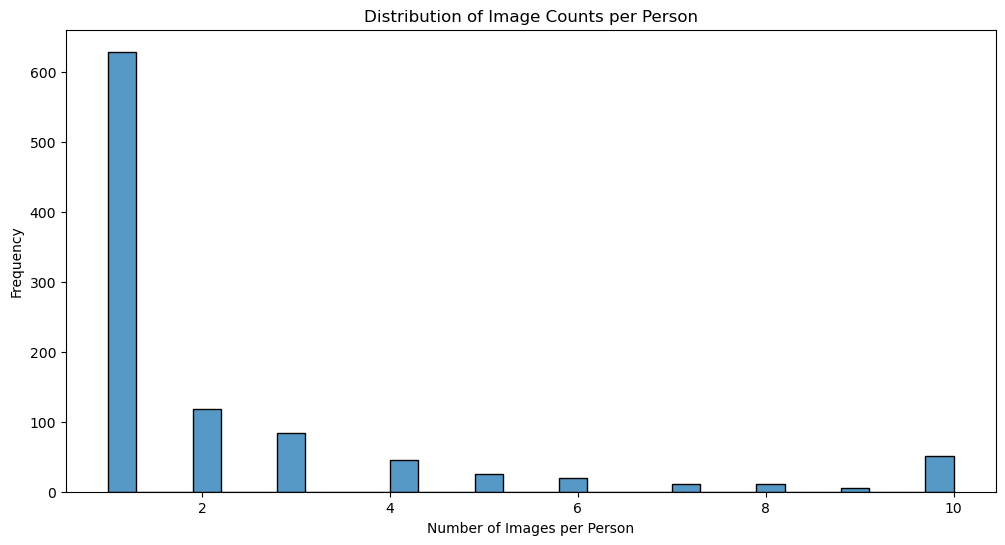

<Figure size 640x480 with 0 Axes>

In [8]:
# Plot the distribution of image counts per person as a histogram
plt.figure(figsize=(12, 6))
sns.histplot(list(category_counts.values()), bins=30, kde=False)
plt.title('Distribution of Image Counts per Person')
plt.xlabel('Number of Images per Person')
plt.ylabel('Frequency')
plt.show()
plt.savefig(os.path.join(output_dir, 'images_per_person.png'))

In [9]:
print("Finding 1: Imbalanced dataset")
for category, count in category_counts.items():
    print(f"Person: {category}, Count: {count}")

Finding 1: Imbalanced dataset
Person: Jude_Law, Count: 1
Person: Steve_Spurrier, Count: 1
Person: Spencer_Abraham, Count: 10
Person: Juan_Manuel_Marquez, Count: 2
Person: Emmanuelle_Beart, Count: 2
Person: Alimzhan_Tokhtakhounov, Count: 1
Person: Intisar_Ajouri, Count: 2
Person: Joseph_Estrada, Count: 3
Person: Jose_Sarney, Count: 2
Person: Sean_Penn, Count: 2
Person: Lord_Hutton, Count: 1
Person: Hal_Sutton, Count: 1
Person: Alexandra_Vodjanikova, Count: 1
Person: Beth_Jones, Count: 1
Person: Camilla_Parker_Bowles, Count: 1
Person: Mario_Dumont, Count: 1
Person: David_Caraway, Count: 1
Person: Jesse_Jackson, Count: 8
Person: Garry_Trudeau, Count: 1
Person: Masum_Turker, Count: 2
Person: Pascal_Quignard, Count: 2
Person: Yoko_Ono, Count: 5
Person: Elizabeth_Shue, Count: 1
Person: Mitoji_Yabunaka, Count: 1
Person: David_Heyman, Count: 1
Person: Pedro_Solbes, Count: 3
Person: Chuck_Yeager, Count: 1
Person: Stellan_Skarsgard, Count: 1
Person: Nasser_al-Kidwa, Count: 1
Person: Courtney_Lov

Each person in the gallery has a different number of images associated with them, between 1 and 10. Most people (>600) have only 1 image associated with them. It is possible to fine-tune the optimal number of images associated with each person for the most accurate facial recognition. 

In [10]:
embedding_sizes = [embedding.shape for _, embedding in embeddings]
unique_embedding_sizes = set(embedding_sizes)
print(f"Unique embedding sizes - {unique_embedding_sizes}")

Unique embedding sizes - {(256,)}


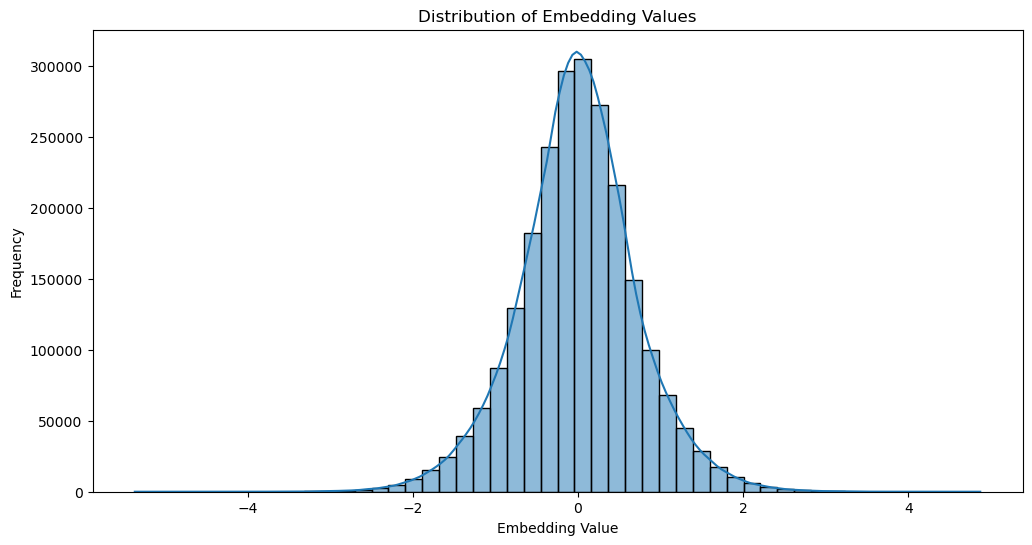

<Figure size 640x480 with 0 Axes>

In [11]:
# Plot the distribution of embedding values
embedding_values = np.concatenate([embedding.flatten() for _, embedding in embeddings])
plt.figure(figsize=(12, 6))
sns.histplot(embedding_values, bins=50, kde=True)
plt.title('Distribution of Embedding Values')
plt.xlabel('Embedding Value')
plt.ylabel('Frequency')
plt.show()
plt.savefig(os.path.join(output_dir, 'embedding_distrubution.png'))

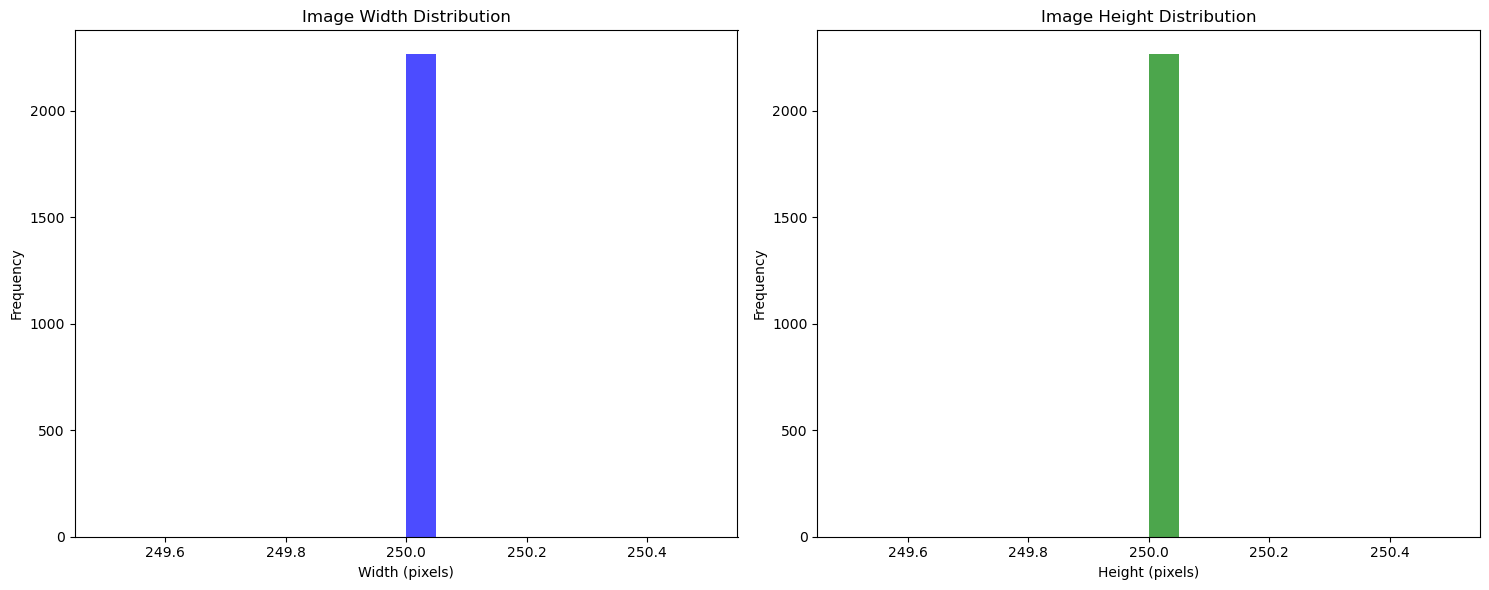

In [12]:
# Analyze the distribution of image sizes
image_sizes = [img.size for _, _, img in images]
widths, heights = zip(*image_sizes)

fig, axs = plt.subplots(1, 2, figsize=(15, 6))
axs[0].hist(widths, bins=20, alpha=0.7, color='blue')
axs[0].set_title('Image Width Distribution')
axs[0].set_xlabel('Width (pixels)')
axs[0].set_ylabel('Frequency')
axs[1].hist(heights, bins=20, alpha=0.7, color='green')
axs[1].set_title('Image Height Distribution')
axs[1].set_xlabel('Height (pixels)')
axs[1].set_ylabel('Frequency')
plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'image_sizes.png'))
plt.show()

All images in the dataset are uniformly sized at 250x250 pixels. This consistency in image dimensions simplifies the preprocessing pipeline, as there is no need for additional resizing or aspect ratio adjustments before feeding the images into the model. Uniform image size ensures that the spatial features extracted by the convolutional layers remain consistent across the dataset, potentially leading to more stable training and better performance.

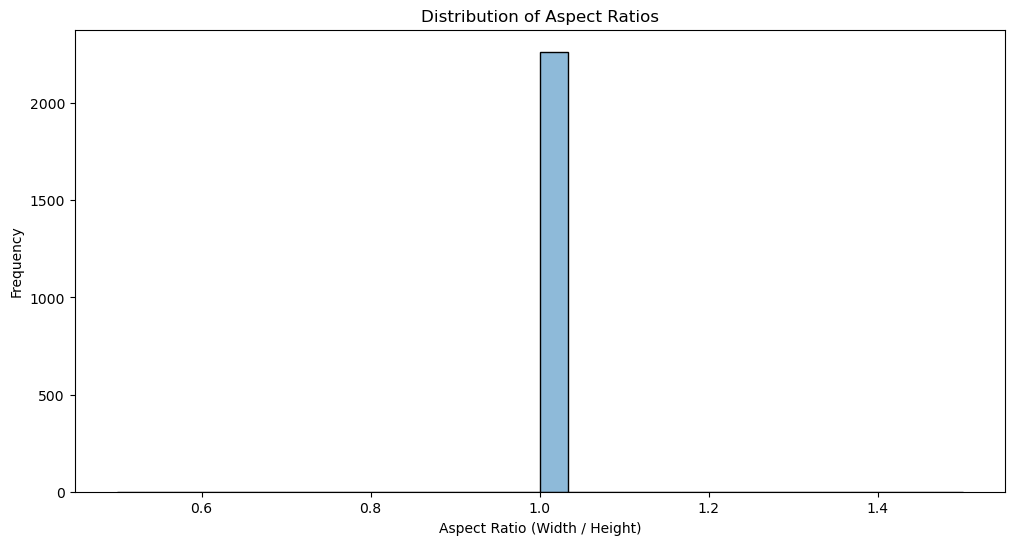

<Figure size 640x480 with 0 Axes>

In [13]:
# Analyze the aspect ratios of the images
aspect_ratios = [w / h for w, h in image_sizes]

plt.figure(figsize=(12, 6))
sns.histplot(aspect_ratios, bins=30, kde=True)
plt.title('Distribution of Aspect Ratios')
plt.xlabel('Aspect Ratio (Width / Height)')
plt.ylabel('Frequency')
plt.show()
plt.savefig(os.path.join(output_dir, 'image_aspect_ratio.png'))

All images in the dataset have a consistent aspect ratio of 1:1, meaning they are perfectly square. This uniformity in aspect ratio simplifies the design of the object detection model, as there is no need to account for variations in image shape that might otherwise complicate the detection process.

/var/folders/fc/n8mdh44s0q1c4gdwdbspc3x40000gn/T/ipykernel_31650/3217916556.py:5: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  sns.countplot(y=image_formats, order = pd.value_counts(image_formats).index)
/var/folders/fc/n8mdh44s0q1c4gdwdbspc3x40000gn/T/ipykernel_31650/3217916556.py:5: FutureWarning: value_counts with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  sns.countplot(y=image_formats, order = pd.value_counts(image_formats).index)


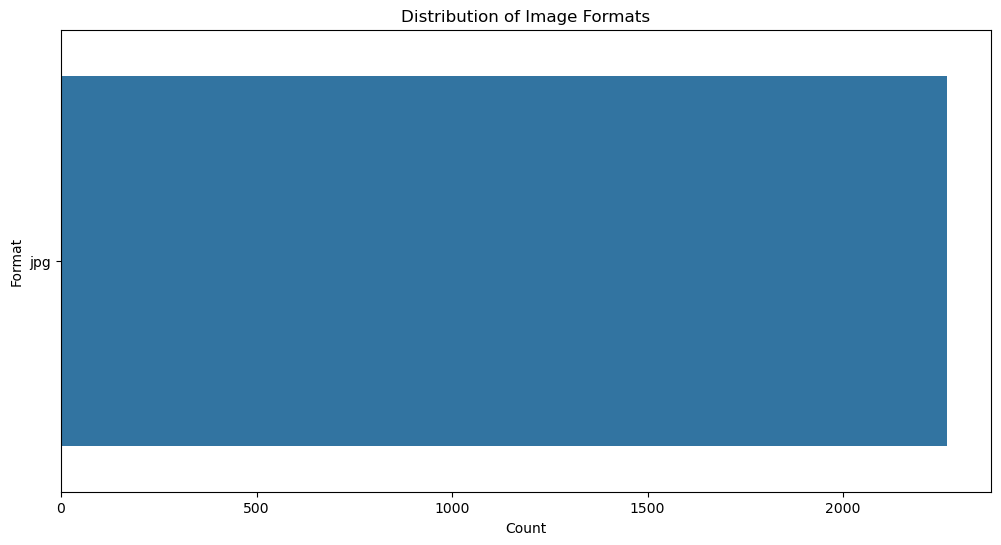

In [14]:
# Analyze the image formats
image_formats = [file.split('.')[-1].lower() for _, file, _ in images]

plt.figure(figsize=(12, 6))
sns.countplot(y=image_formats, order = pd.value_counts(image_formats).index)
plt.title('Distribution of Image Formats')
plt.xlabel('Count')
plt.ylabel('Format')
plt.savefig(os.path.join(output_dir, 'image_format_distribution.png'))
plt.show()

All images in the dataset are in JPEG format, which is a widely used and efficient format for image compression. This consistency simplifies the preprocessing pipeline, as the model only needs to handle a single image format, reducing the potential for errors related to format conversion.

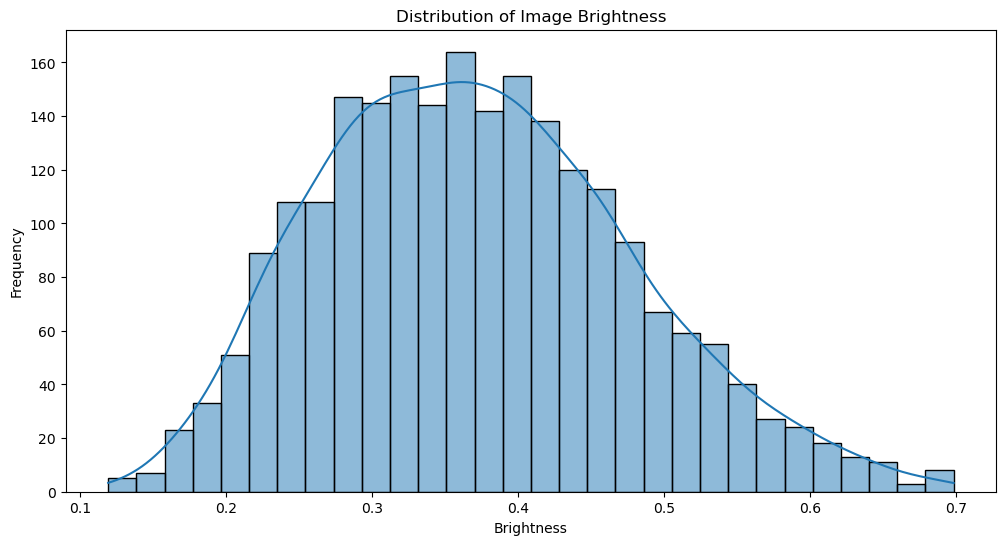

In [15]:
# Analyze the brightness of the images
def calculate_brightness(image):
    grayscale_image = image.convert('L')
    histogram = grayscale_image.histogram()
    pixels = sum(histogram)
    brightness = scale = len(histogram)
    for index in range(scale):
        ratio = histogram[index] / pixels
        brightness += ratio * (index - scale)
    return 1 if brightness == 255 else brightness / scale

brightness_values = [calculate_brightness(img) for _, _, img in images]

plt.figure(figsize=(12, 6))
sns.histplot(brightness_values, bins=30, kde=True)
plt.title('Distribution of Image Brightness')
plt.xlabel('Brightness')
plt.ylabel('Frequency')
plt.savefig(os.path.join(output_dir, 'image_brightness_distribution.png'))
plt.show()

The images in the gallery appears to exhibit a normal distribution for mean brightness. This indicates that the lighting conditions are relatively consistent across the dataset, with most images having an average brightness level centered around a common mean. Such uniformity in brightness simplifies the model's task of learning relevant features, as it reduces the variability in pixel intensity caused by differing lighting conditions. However, it is still essential to ensure that the model can handle variations in lighting that might occur in real-world scenarios. To enhance the model's robustness to different lighting conditions, data augmentation techniques such as brightness and contrast adjustments should be applied during training.